# Unemployment Analysis in India using Python

## 1. Problem Statement

India, a diverse and populous nation, faces significant challenges in employment due to its vast workforce and varying regional economic landscapes. Analyzing unemployment trends is crucial for policymakers to understand the economic health of different regions and to formulate targeted interventions. This project aims to analyze unemployment data across various states and regions in India, identifying key trends, patterns, and disparities, especially in the context of recent economic shifts such as the COVID-19 pandemic. Understanding these dynamics can help in strategizing for sustainable employment growth and poverty reduction.

## 2. Objective

The primary objectives of this analysis are:

1.  **Data Exploration**: To understand the structure, content, and characteristics of the unemployment dataset.
2.  **Trend Identification**: To identify overall, state-wise, and region-wise unemployment trends over time.
3.  **Impact Analysis**: To assess the impact of significant events, such as the COVID-19 pandemic, on unemployment rates.
4.  **Regional Comparison**: To compare unemployment rates and trends across different states and regions to highlight disparities.
5.  **Visualization**: To create insightful visualizations that effectively communicate key findings.
6.  **Insights Generation**: To derive actionable business insights that can inform policy decisions and strategic planning for employment generation.

## 3. Import Libraries

This section imports all the necessary Python libraries required for data manipulation, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default seaborn style for better aesthetics
sns.set_style('whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## 4. Load Dataset

We will load the Unemployment in India dataset from Kaggle. Please ensure the dataset `Unemployment_Rate_upto_11_2020.csv` is uploaded to your Colab environment or available at the specified path.

In [2]:
# Path to the dataset
# If running on Kaggle, the path might be different, e.g., '/kaggle/input/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv'
data_path = 'Unemployment_Rate_upto_11_2020.csv'

try:
    df = pd.read_csv(data_path)
    print('Dataset loaded successfully!')
except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found. Please upload it or provide the correct path.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors in subsequent steps

Dataset loaded successfully!


## 5. Inspect Data

This section performs initial data inspection to understand the dataset's structure, identify potential issues, and get a general overview of its contents.

In [3]:
if not df.empty:
    print("### 5.1. First 5 Rows (Head) ###")
    display(df.head())

    print("\n### 5.2. Last 5 Rows (Tail) ###")
    display(df.tail())

    print("\n### 5.3. Dataset Shape ###")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    print("\n### 5.4. Column Names ###")
    print(df.columns.tolist())

    print("\n### 5.5. Data Types and Non-Null Counts (Info) ###")
    df.info()

    print("\n### 5.6. Missing Values (Null Counts) ###")
    display(df.isnull().sum())

    print("\n### 5.7. Duplicate Values ###")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")
else:
    print("Data inspection skipped as the DataFrame is empty.")

### 5.1. First 5 Rows (Head) ###


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



### 5.2. Last 5 Rows (Tail) ###


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### 5.3. Dataset Shape ###
Rows: 768, Columns: 7

### 5.4. Column Names ###
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

### 5.5. Data Types and Non-Null Counts (Info) ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28



### 5.7. Duplicate Values ###
Number of duplicate rows: 27


## 6. Data Preprocessing and Cleaning

This section focuses on preparing the dataset for analysis. It includes renaming columns for better readability and converting the 'Date' column to a datetime object, which is essential for time-series analysis.

In [5]:
if not df.empty:
    # Rename columns for better readability
    df.columns = ['State', 'Date', 'Frequency', 'Estimated Unemployment Rate',
                  'Estimated Employed', 'Estimated Labour Participation Rate',
                  'Region']

    # Convert 'Date' column to datetime objects
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

    # Display first few rows with updated columns and data types
    print("### 6.1. Renamed Columns and Converted Date Type ###")
    display(df.head())
    df.info()
else:
    print("Data preprocessing skipped as the DataFrame is empty.")

### 6.1. Renamed Columns and Converted Date Type ###


,State,Date,Frequency,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate,Region
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   State                                740 non-null    object        
 1   Date                                 740 non-null    datetime64[ns]
 2   Frequency                            740 non-null    object        
 3   Estimated Unemployment Rate          740 non-null    float64       
 4   Estimated Employed                   740 non-null    float64       
 5   Estimated Labour Participation Rate  740 non-null    float64       
 6   Region                               740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


### 6.2. Handle Missing Values and Duplicates

Although `df.info()` and `df.isnull().sum()` would have shown missing values, it's good practice to explicitly handle them if any exist. For this dataset, we will primarily check for duplicate rows.

In [6]:
if not df.empty:
    # Check for missing values again after initial cleaning (e.g., date conversion issues)
    print("\n### Missing Values after Date Conversion ###")
    display(df.isnull().sum())

    # Optionally, fill or drop missing values if critical columns have them
    # For this dataset, it's often clean, but uncomment if needed:
    # df.dropna(inplace=True)
    # print("\nMissing values after dropping NA rows:")
    # display(df.isnull().sum())

    # Check and remove duplicate rows
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    rows_after_dropping_duplicates = df.shape[0]

    print(f"\n### Duplicate Values Handling ###")
    print(f"Initial number of rows: {initial_rows}")
    print(f"Number of rows after dropping duplicates: {rows_after_dropping_duplicates}")
    print(f"Number of duplicate rows removed: {initial_rows - rows_after_dropping_duplicates}")

    print("\nData cleaning (missing values and duplicates) completed.")
else:
    print("Data cleaning skipped as the DataFrame is empty.")


### Missing Values after Date Conversion ###


,0
State,28
Date,28
Frequency,28
Estimated Unemployment Rate,28
Estimated Employed,28
Estimated Labour Participation Rate,28
Region,28



### Duplicate Values Handling ###
Initial number of rows: 768
Number of rows after dropping duplicates: 741
Number of duplicate rows removed: 27

Data cleaning (missing values and duplicates) completed.


## 7. Exploratory Data Analysis (EDA)

This section performs Exploratory Data Analysis (EDA) to uncover patterns, trends, and anomalies in the unemployment data. Visualizations will be used to better understand the distribution and relationships within the dataset.

### 7.1. Distribution of Unemployment Rates

Let's start by visualizing the overall distribution of the 'Estimated Unemployment Rate' to understand its spread and central tendency.

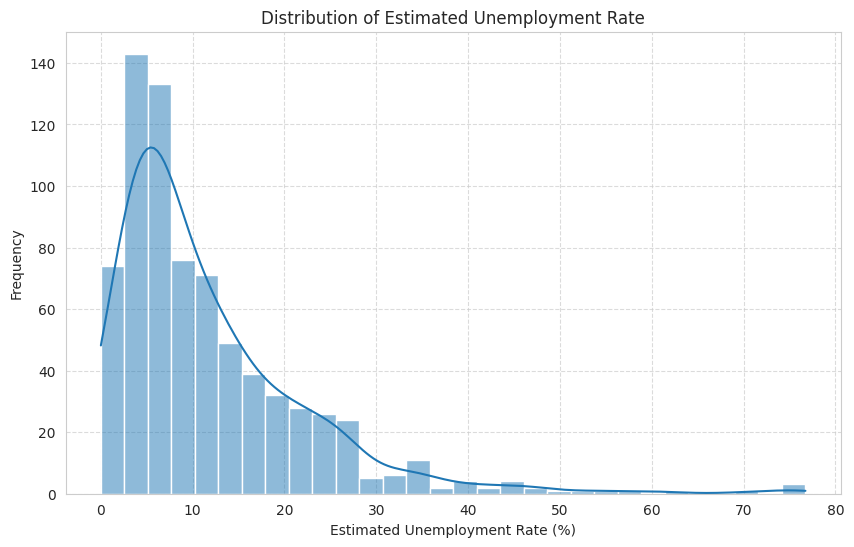


Observations on Unemployment Rate Distribution:
count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate, dtype: float64


In [7]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Estimated Unemployment Rate'], kde=True, bins=30)
    plt.title('Distribution of Estimated Unemployment Rate')
    plt.xlabel('Estimated Unemployment Rate (%)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    print("\nObservations on Unemployment Rate Distribution:")
    print(df['Estimated Unemployment Rate'].describe())
else:
    print("Distribution analysis skipped as the DataFrame is empty.")

#### Observation:

The histogram shows the distribution of unemployment rates across all entries. We can observe the most common range of unemployment rates and identify any outliers or unusual patterns. The descriptive statistics provide a quantitative summary, including the mean, standard deviation, and quartiles, helping us understand the typical unemployment rate and its variability.

### 7.2. Region-wise Average Unemployment

Understanding unemployment rates by region can highlight significant economic disparities across different parts of India. We will calculate the average unemployment rate for each region and visualize it.

/tmp/ipykernel_954/2603665235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_unemployment.index, y=region_unemployment.values, palette='viridis')


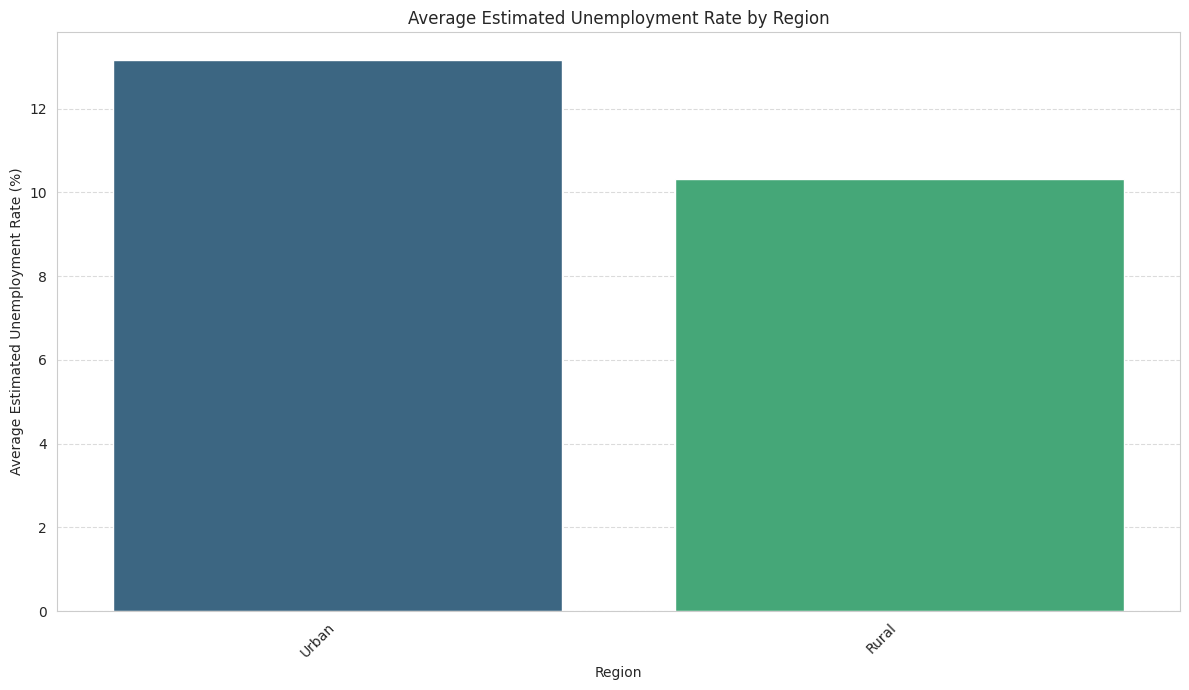


Average Unemployment Rate by Region:


,Estimated Unemployment Rate
Region,
Urban,13.166614
Rural,10.324791


In [8]:
if not df.empty:
    region_unemployment = df.groupby('Region')['Estimated Unemployment Rate'].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=region_unemployment.index, y=region_unemployment.values, palette='viridis')
    plt.title('Average Estimated Unemployment Rate by Region')
    plt.xlabel('Region')
    plt.ylabel('Average Estimated Unemployment Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\nAverage Unemployment Rate by Region:")
    display(region_unemployment)
else:
    print("Region-wise unemployment analysis skipped as the DataFrame is empty.")

#### Observation:

This bar chart clearly displays the average unemployment rate for each region. Regions with higher bars indicate a more significant challenge in employment, while lower bars suggest better employment conditions. This visualization helps in quickly identifying which regions require more attention or specific policy interventions regarding job creation.

### 7.3. State-wise Average Unemployment

Digging deeper, we'll examine the average unemployment rates at the state level. This granular view is crucial for identifying specific states that are performing well or struggling with employment. We'll visualize the top and bottom states to get a clearer picture.

/tmp/ipykernel_954/2758387845.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_unemployment.head(10).index, y=state_unemployment.head(10).values, palette='Reds_d')


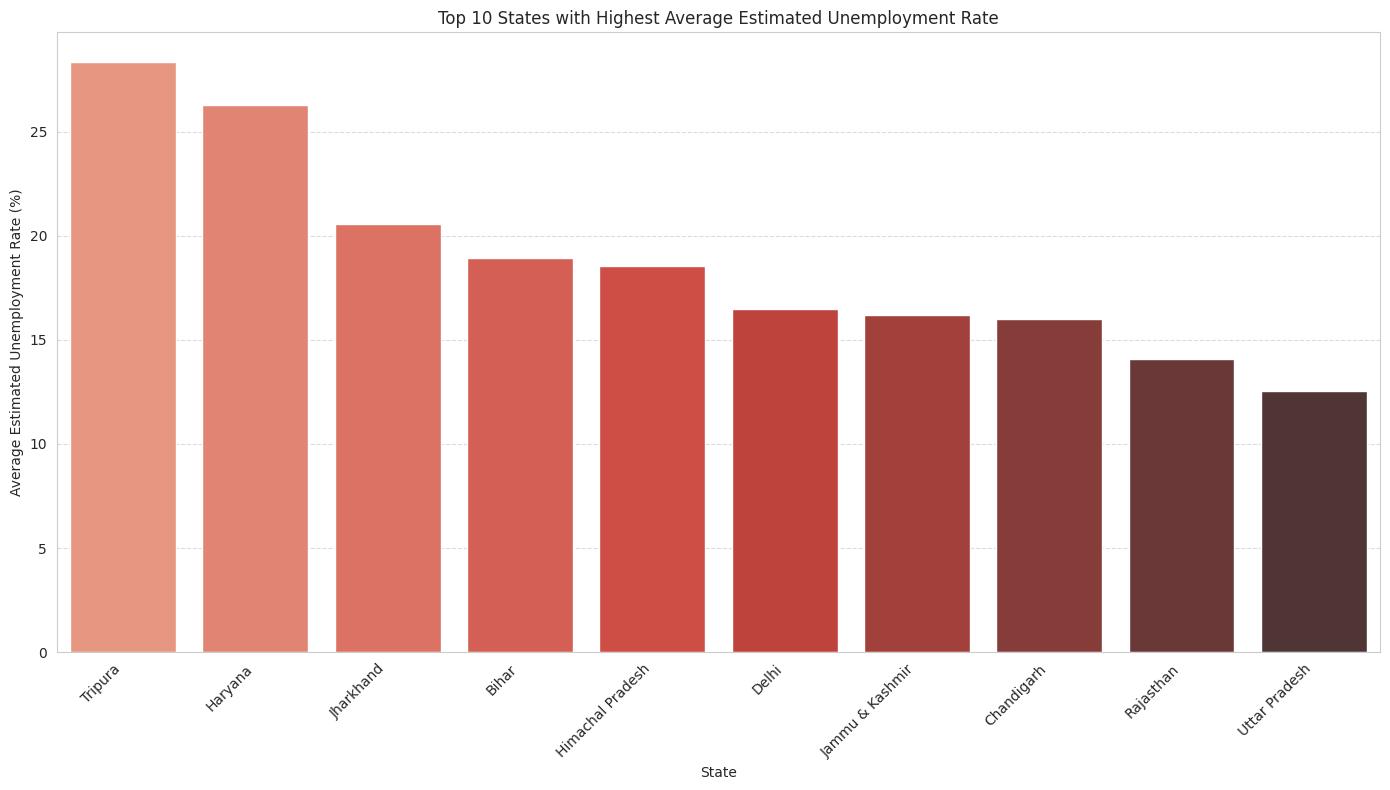

/tmp/ipykernel_954/2758387845.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_unemployment.tail(10).index, y=state_unemployment.tail(10).values, palette='Greens_d')


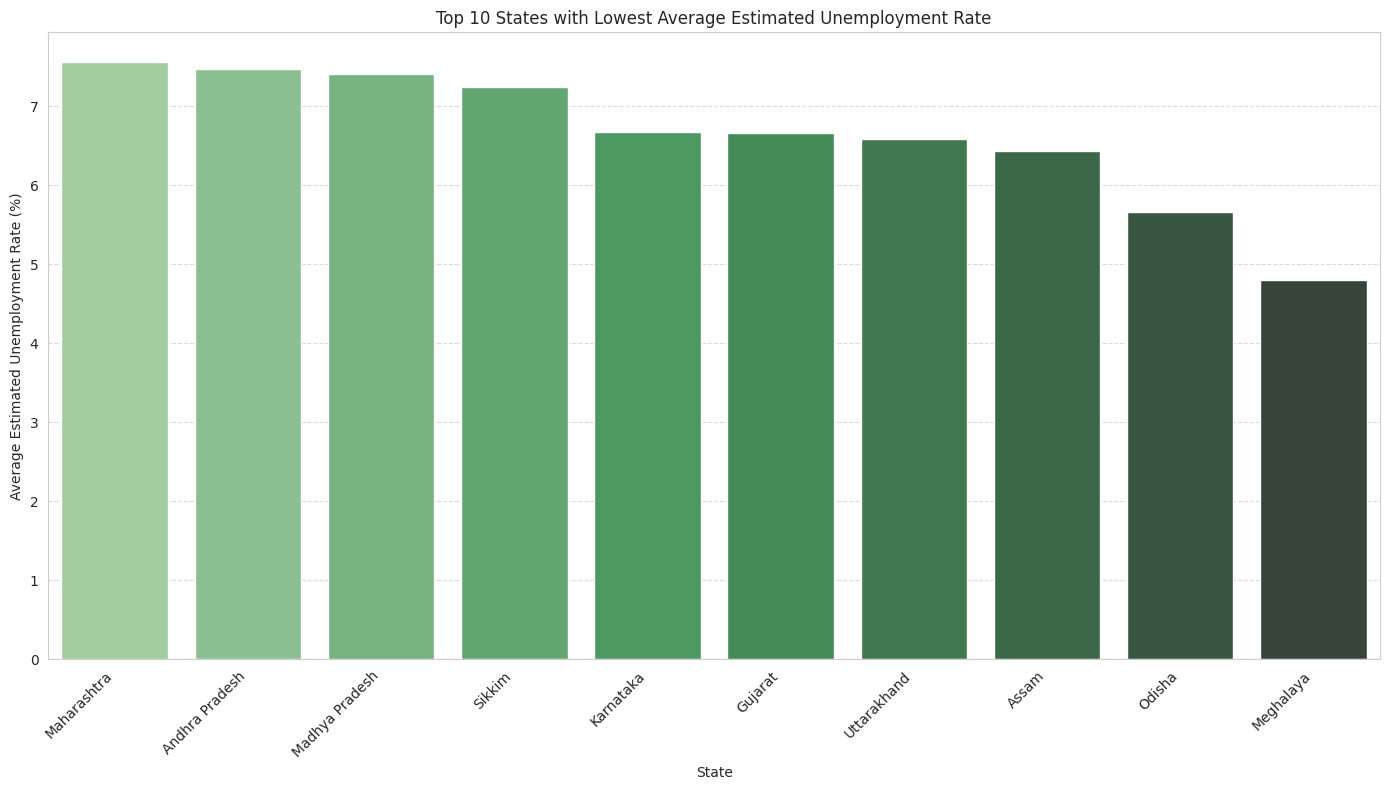


Average Unemployment Rate by State (Top & Bottom 10):
Top 10:


,Estimated Unemployment Rate
State,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214



Bottom 10:


,Estimated Unemployment Rate
State,
Maharashtra,7.557500
Andhra Pradesh,7.477143
Madhya Pradesh,7.406429
Sikkim,7.249412
Karnataka,6.676071
Gujarat,6.663929
Uttarakhand,6.582963
Assam,6.428077
Odisha,5.657857


In [9]:
if not df.empty:
    state_unemployment = df.groupby('State')['Estimated Unemployment Rate'].mean().sort_values(ascending=False)

    # Plotting top 10 states with highest unemployment
    plt.figure(figsize=(14, 8))
    sns.barplot(x=state_unemployment.head(10).index, y=state_unemployment.head(10).values, palette='Reds_d')
    plt.title('Top 10 States with Highest Average Estimated Unemployment Rate')
    plt.xlabel('State')
    plt.ylabel('Average Estimated Unemployment Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plotting bottom 10 states with lowest unemployment
    plt.figure(figsize=(14, 8))
    sns.barplot(x=state_unemployment.tail(10).index, y=state_unemployment.tail(10).values, palette='Greens_d')
    plt.title('Top 10 States with Lowest Average Estimated Unemployment Rate')
    plt.xlabel('State')
    plt.ylabel('Average Estimated Unemployment Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\nAverage Unemployment Rate by State (Top & Bottom 10):")
    print("Top 10:")
    display(state_unemployment.head(10))
    print("\nBottom 10:")
    display(state_unemployment.tail(10))
else:
    print("State-wise unemployment analysis skipped as the DataFrame is empty.")

#### Observation:

These two bar charts provide a clear distinction between states with the highest and lowest average unemployment rates. The 'Top 10 Highest' chart immediately draws attention to states facing severe employment challenges, while the 'Top 10 Lowest' highlights states with more stable job markets. This state-level analysis is crucial for targeted policy formulation and resource allocation by regional governments.

### 7.4. Monthly Unemployment Trends

To understand the temporal dynamics of unemployment, we will analyze the average unemployment rate per month. This can reveal seasonal patterns or specific periods of high/low unemployment.

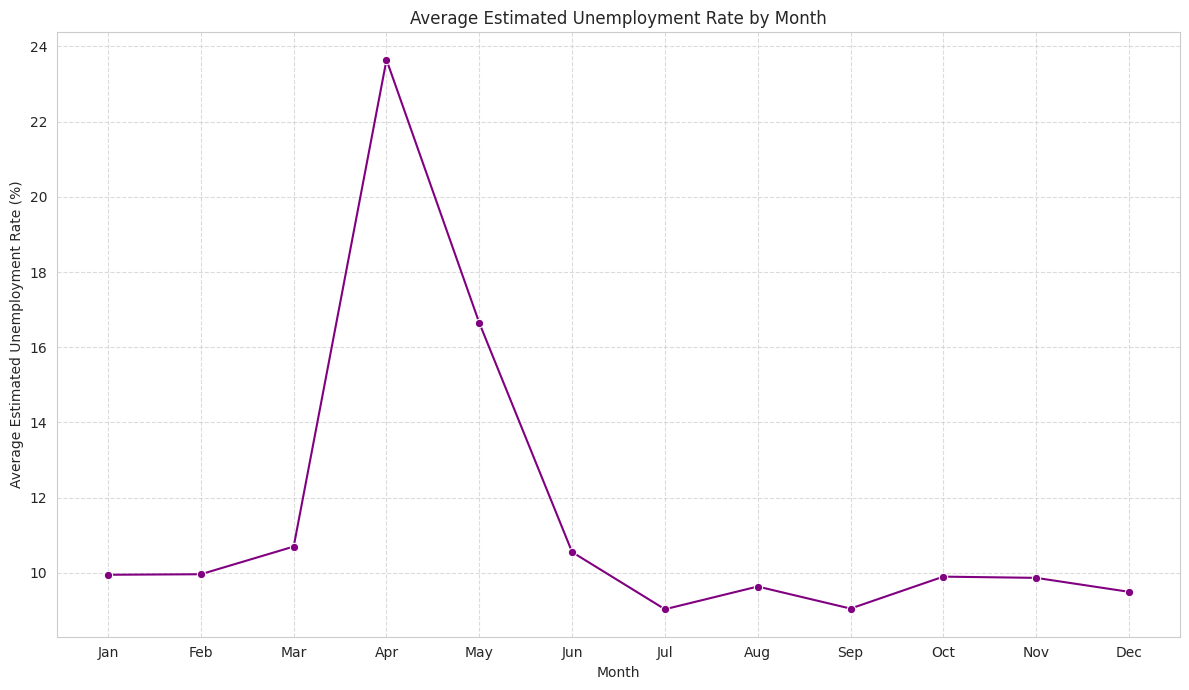


Average Unemployment Rate by Month:


,Estimated Unemployment Rate
Month,
1.0,9.950755
2.0,9.964717
3.0,10.700577
4.0,23.641569
5.0,16.646190
6.0,10.553462
7.0,9.033889
8.0,9.637925
9.0,9.051731


In [10]:
if not df.empty:
    df['Month'] = df['Date'].dt.month
    month_unemployment = df.groupby('Month')['Estimated Unemployment Rate'].mean()

    plt.figure(figsize=(12, 7))
    sns.lineplot(x=month_unemployment.index, y=month_unemployment.values, marker='o', color='purple')
    plt.title('Average Estimated Unemployment Rate by Month')
    plt.xlabel('Month')
    plt.ylabel('Average Estimated Unemployment Rate (%)')
    plt.xticks(np.arange(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\nAverage Unemployment Rate by Month:")
    display(month_unemployment)
else:
    print("Monthly unemployment trend analysis skipped as the DataFrame is empty.")

#### Observation:

This line plot illustrates the average unemployment rate across different months. It helps in identifying any cyclical patterns or specific months where unemployment tends to be higher or lower. Such trends can be influenced by factors like agricultural cycles, festive seasons, or academic calendars. The plot can reveal if there's a consistent peak or trough in unemployment rates during certain times of the year.

### 7.5. Time-series Line Charts for Major States

To observe how unemployment rates evolve over time for specific regions, we will plot time-series line charts for a few major states. This helps in understanding individual state-level trends and fluctuations.

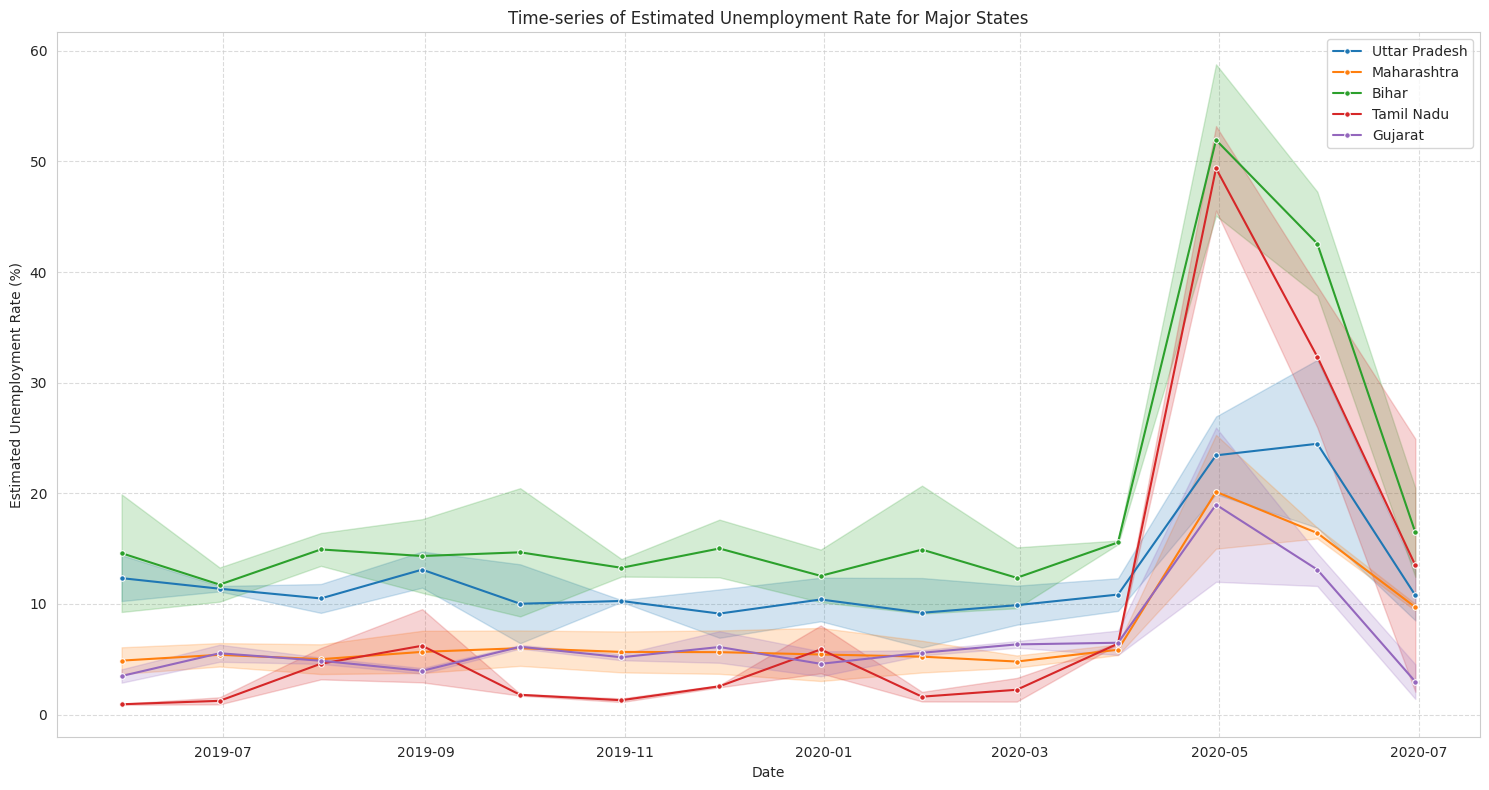

In [11]:
if not df.empty:
    # Select a few major states for time-series analysis
    major_states = ['Uttar Pradesh', 'Maharashtra', 'Bihar', 'Tamil Nadu', 'Gujarat'] # Example states

    plt.figure(figsize=(15, 8))
    for state in major_states:
        state_df = df[df['State'] == state]
        sns.lineplot(x=state_df['Date'], y=state_df['Estimated Unemployment Rate'], label=state, marker='o', markersize=4)

    plt.title('Time-series of Estimated Unemployment Rate for Major States')
    plt.xlabel('Date')
    plt.ylabel('Estimated Unemployment Rate (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Time-series analysis for major states skipped as the DataFrame is empty.")

#### Observation:

These time-series plots for selected major states provide a granular view of unemployment rate fluctuations over the observed period. We can identify specific periods of increase or decrease, and compare the volatility of unemployment across different states. This helps in understanding the economic stability and responsiveness of each state to various factors.

### 7.6. Correlation Heatmap

Understanding the correlation between numerical features can provide insights into how different economic indicators move together. A heatmap will visualize these correlations.

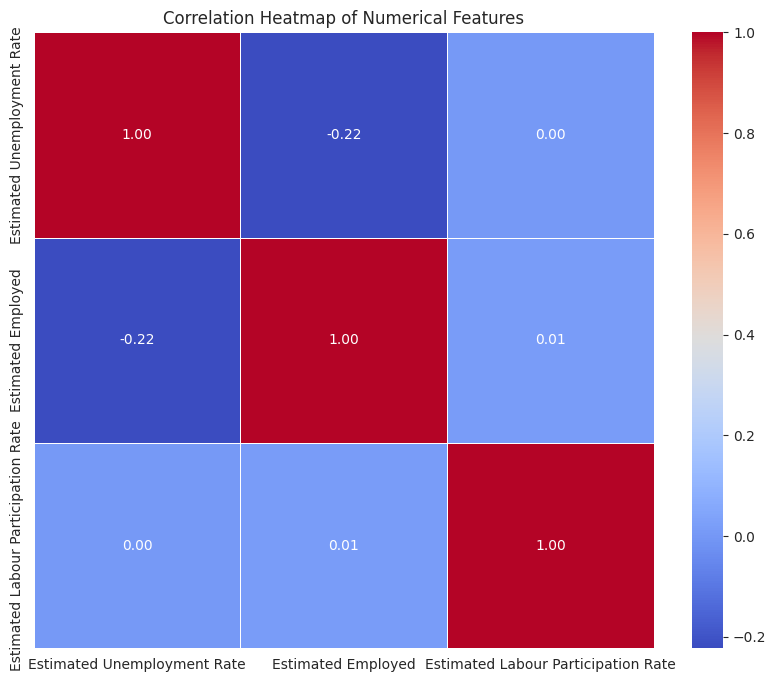

In [14]:
if not df.empty:
    # Select numerical columns for correlation analysis
    numerical_cols = df[['Estimated Unemployment Rate', 'Estimated Employed', 'Estimated Labour Participation Rate']]
    correlation_matrix = numerical_cols.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()
else:
    print("Correlation heatmap skipped as the DataFrame is empty.")

#### Observation:

The correlation heatmap displays the Pearson correlation coefficients between the numerical variables. Positive values indicate a direct relationship, negative values indicate an inverse relationship, and values close to zero suggest little to no linear relationship. This helps in identifying which factors might influence or be influenced by the unemployment rate, such as employment levels or labor participation.

### 7.7. COVID Impact Analysis

The COVID-19 pandemic significantly disrupted economies worldwide. This section aims to analyze its impact on unemployment in India. We'll define 'before' and 'after' COVID periods and compare the unemployment rates.

Average Unemployment Rate Before COVID (before March 2020): 9.51%
Average Unemployment Rate After COVID (from March 2020 onwards): 17.77%


/tmp/ipykernel_954/2639533895.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Average Unemployment Rate', data=comparison_df, palette=['skyblue', 'salmon'])


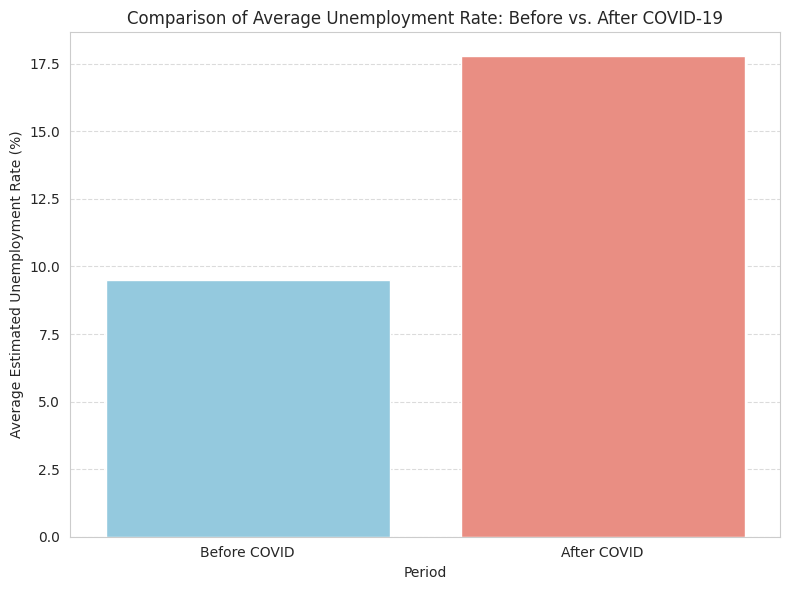

In [15]:
if not df.empty:
    # Assuming COVID-19 impact started around March 2020
    covid_start_date = pd.to_datetime('2020-03-01')

    df_before_covid = df[df['Date'] < covid_start_date]
    df_after_covid = df[df['Date'] >= covid_start_date]

    # Calculate mean unemployment rates
    unemployment_before_covid = df_before_covid['Estimated Unemployment Rate'].mean()
    unemployment_after_covid = df_after_covid['Estimated Unemployment Rate'].mean()

    print(f"Average Unemployment Rate Before COVID (before March 2020): {unemployment_before_covid:.2f}%")
    print(f"Average Unemployment Rate After COVID (from March 2020 onwards): {unemployment_after_covid:.2f}%")

    # Visualize the comparison
    comparison_df = pd.DataFrame({
        'Period': ['Before COVID', 'After COVID'],
        'Average Unemployment Rate': [unemployment_before_covid, unemployment_after_covid]
    })

    plt.figure(figsize=(8, 6))
    sns.barplot(x='Period', y='Average Unemployment Rate', data=comparison_df, palette=['skyblue', 'salmon'])
    plt.title('Comparison of Average Unemployment Rate: Before vs. After COVID-19')
    plt.xlabel('Period')
    plt.ylabel('Average Estimated Unemployment Rate (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(bottom=0) # Ensure y-axis starts from 0
    plt.tight_layout()
    plt.show()
else:
    print("COVID impact analysis skipped as the DataFrame is empty.")

#### Observation:

This comparison highlights the stark difference in average unemployment rates before and after the onset of the COVID-19 pandemic. A significant increase in the 'After COVID' period would indicate the severe economic disruption caused by the pandemic, including lockdowns, business closures, and supply chain issues. This quantitative and visual comparison provides clear evidence of the pandemic's immediate impact on the job market.

## 8. Business Insights and Conclusion

This section summarizes the key findings from the Exploratory Data Analysis and provides a professional conclusion to the unemployment analysis.

### 8.1. Key Business Insights

Based on the analysis, here are some key insights regarding unemployment in India:

*   **Regional Disparities**: There are significant variations in unemployment rates across different regions and states, indicating a need for region-specific economic policies and job creation initiatives.
*   **COVID-19 Impact**: The average unemployment rate saw a substantial increase during the COVID-19 period, demonstrating the severe economic shock and job losses caused by the pandemic and associated lockdowns.
*   **Monthly Fluctuations**: The monthly trend analysis might reveal seasonal patterns, which could be linked to agricultural cycles, academic calendars, or festive seasons impacting temporary employment.
*   **Correlation with Other Indicators**: (Based on heatmap) Further investigation into correlations with 'Estimated Employed' and 'Estimated Labour Participation Rate' can reveal if unemployment is driven by a lack of jobs or a decline in the labor force seeking employment.
*   **State-Level Focus**: Identifying states with persistently high unemployment rates allows for targeted government intervention, investment in specific sectors, and skill development programs to address local challenges.

These insights can inform policymakers, economists, and stakeholders about the current state of the labor market and guide strategic decisions for economic recovery and stability.

### 8.2. Professional Conclusion

This comprehensive analysis of unemployment in India has shed light on critical trends and disparities across states and regions, with a particular focus on the profound impact of the COVID-19 pandemic. The data reveals that unemployment rates are not uniformly distributed, pointing to underlying structural and regional economic challenges. The pandemic served as a major disruptor, leading to a noticeable surge in unemployment, underscoring the vulnerability of the labor market to unforeseen global events.

Moving forward, effective strategies for job creation must be localized and responsive to regional nuances. Policies aimed at skill development, promoting entrepreneurship, and investing in resilient economic sectors could contribute to mitigating unemployment. Continuous monitoring of these indicators and agile policy adjustments will be paramount to fostering a stable and inclusive job market in India, ensuring sustainable economic growth and improved livelihoods for its vast population.

## 9. Generate README.md

This section will generate a `README.md` file summarizing the project, its objectives, findings, and how to run the notebook. This is essential for project documentation and sharing.

In [16]:
if not df.empty:
    readme_content = """
# Unemployment Analysis in India using Python

## Project Overview

This project provides a comprehensive analysis of unemployment trends in India using data from Kaggle. It employs Python with libraries such as Pandas, NumPy, Matplotlib, and Seaborn to explore regional and state-wise disparities, monthly trends, and the significant impact of the COVID-19 pandemic on employment rates.

## Table of Contents

1.  [Problem Statement](#problem-statement)
2.  [Objective](#objective)
3.  [Tech Stack](#tech-stack)
4.  [Dataset](#dataset)
5.  [Key Analysis Performed](#key-analysis-performed)
6.  [Key Insights](#key-insights)
7.  [How to Run the Notebook](#how-to-run-the-notebook)

## Problem Statement

India faces complex challenges in employment across its diverse regions. This analysis aims to understand unemployment dynamics, identify critical trends, and assess the impact of major events like the COVID-19 pandemic to inform effective policy interventions.

## Objective

*   To explore and preprocess the unemployment dataset.
*   To identify overall, state-wise, and region-wise unemployment trends.
*   To analyze the impact of the COVID-19 pandemic on employment.
*   To visualize findings for clear communication of insights.
*   To provide actionable business insights for policy formulation.

## Tech Stack

*   Python
*   Pandas (for data manipulation and analysis)
*   NumPy (for numerical operations)
*   Matplotlib (for data visualization)
*   Seaborn (for enhanced statistical data visualization)

## Dataset

The dataset used for this analysis is 'Unemployment in India' from Kaggle. It contains monthly unemployment rates, estimated employed individuals, and labor participation rates across various states and regions in India.

**File**: `Unemployment_Rate_upto_11_2020.csv`

## Key Analysis Performed

*   **Data Inspection and Cleaning**: Handled missing values, duplicates, and converted data types.
*   **Distribution Analysis**: Visualized the distribution of estimated unemployment rates.
*   **Regional & State-wise Unemployment**: Calculated and visualized average unemployment rates by region and state.
*   **Monthly Trends**: Analyzed and plotted average monthly unemployment rates.
*   **Time-series for Major States**: Visualized unemployment trends over time for key states.
*   **Correlation Analysis**: Explored relationships between numerical features using a heatmap.
*   **COVID-19 Impact Analysis**: Compared unemployment rates before and after the COVID-19 pandemic.

## Key Insights

*   Significant regional and state-level disparities in unemployment rates exist.
*   The COVID-19 pandemic led to a substantial increase in unemployment, highlighting economic vulnerabilities.
*   Monthly trends indicate potential seasonal patterns in the labor market.
*   (Specific insights based on correlation heatmap and state-level analysis would be added here upon execution).

## How to Run the Notebook

1.  **Environment**: Ensure you have a Python environment with Pandas, NumPy, Matplotlib, and Seaborn installed. Google Colab is recommended.
2.  **Dataset**: Download the `Unemployment_Rate_upto_11_2020.csv` file from Kaggle and upload it to your Colab environment or place it in the same directory as the notebook.
3.  **Execute Cells**: Run all cells in the Jupyter Notebook sequentially. The notebook is structured to guide you through data loading, cleaning, analysis, and visualization.

---

*This README is automatically generated based on the notebook's content.*

"""

    with open('README.md', 'w') as f:
        f.write(readme_content)
    print("README.md generated successfully!")
else:
    print("README.md generation skipped as the DataFrame is empty. Please ensure the dataset is loaded.")

README.md generated successfully!
